In [ ]:
!pip install torch_snippets # instala biblioteca para PyTorch
from torch_snippets import * # importa as funções da biblioteca
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
from torchvision import datasets

data_folder = './CIFAR10'
datasets.CIFAR10(data_folder, download=True)

100%|██████████| 170M/170M [00:03<00:00, 51.4MB/s]


Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./CIFAR10
    Split: Train

In [ ]:
class Colorize(torchvision.datasets.CIFAR10): # herda a estrutura do dataset
    def __init__(self, root, train):
        super().__init__(root, train) # inicializa a classe

    def __getitem__(self, ix):
        im, _ = super().__getitem__(ix) # pega a imagem original
        bw = im.convert('L').convert('RGB')
        bw, im = np.array(bw)/255., np.array(im)/255.
        bw, im = [torch.tensor(i).permute(2,0,1).to(device).float() for i in [bw,im]]
        return bw, im # retorna o par (entrada em P&B, alvo colorido)

# instanciando os datasets
trn_ds = Colorize(data_folder, train=True)
val_ds = Colorize(data_folder, train=False)

# cria os DataLoaders
trn_dl = DataLoader(trn_ds, batch_size=256, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

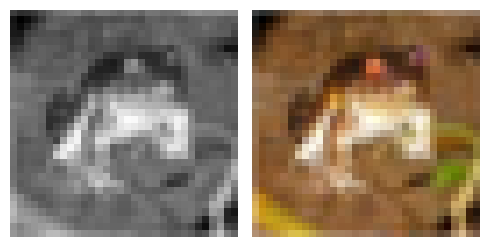

In [ ]:
a,b = trn_ds[0]
subplots([a,b], nc=2)

In [ ]:
import torch.nn as nn

class Identity(nn.Module): # camada que não altera o dado apenas o retorna
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return x

class DownConv(nn.Module): # bloco de contração
    def __init__(self, ni, no, maxpool=True):
        super().__init__()
        self.model = nn.Sequential(
            nn.MaxPool2d(2) if maxpool else Identity(), # reduz a imagem pela metade
            nn.Conv2d(ni, no, 3, padding=1), # primeira convolução para extrair
            nn.BatchNorm2d(no), # normalização para estabilizar
            nn.LeakyReLU(0.2, inplace=True), # ativação que permite pequenos valores
            nn.Conv2d(no, no, 3, padding=1), # segunda convolução
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x):
        return self.model(x)

class UpConv(nn.Module): # bloco de expansão
    def __init__(self, ni, no):
        super().__init__()
        self.convtranspose = nn.ConvTranspose2d(ni, no, 2, stride=2)
        self.convlayers = nn.Sequential(
            nn.Conv2d(no+no, no, 3, padding=1), # recebe entrada concatenada
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(no, no, 3, padding=1),
            nn.BatchNorm2d(no),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x, y):
        x = self.convtranspose(x)
        x = torch.cat([x, y], axis=1) # concatena os mapas de características
        x = self.convlayers(x)
        return x

class UNet(nn.Module):
    def __init__(self):
        super().__init__() # Caminho descendente
        self.d1 = DownConv(3, 64, maxpool=False)
        self.d2 = DownConv(64, 128)
        self.d3 = DownConv(128, 256)
        self.d4 = DownConv(256, 512)
        self.d5 = DownConv(512, 1024)

        # Caminho ascendente
        self.u5 = UpConv(1024, 512)
        self.u4 = UpConv(512, 256)
        self.u3 = UpConv(256, 128)
        self.u2 = UpConv(128, 64)

        # Camada final
        self.u1 = nn.Conv2d(64, 3, kernel_size=1, stride=1)

    def forward(self, x):
        # Down-sampling
        x0 = self.d1(x)
        x1 = self.d2(x0)
        x2 = self.d3(x1)
        x3 = self.d4(x2)
        x4 = self.d5(x3)

        # Up-sampling
        X4 = self.u5(x4, x3)
        X3 = self.u4(X4, x2)
        X2 = self.u3(X3, x1)
        X1 = self.u2(X2, x0)
        X0 = self.u1(X1)

        return X0

In [ ]:
def get_model():
    model = UNet().to(device) # instancia a UNet
    optimizer = optim.Adam(model.parameters(), lr=1e-3) # define o otimizador Adam
    loss_fn = nn.MSELoss()
    return model, optimizer, loss_fn

In [ ]:
def train_batch(model, data, optimizer, criterion):
    model.train() # coloca o modelo em modo de treinamento
    x, y = data # desempacota os dados
    _y = model(x) # executa o forward
    optimizer.zero_grad() # limpa
    loss = criterion(_y, y) # calcula o erro
    loss.backward() # executa o backpropagation
    optimizer.step() # atualiza os pesos do modelo
    return loss.item() # retorna o valor

@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval() # coloca o modelo em modo de avaliação
    x, y = data # desempacota os dados de validação
    _y = model(x) # o modelo tenta colorir a imagem de teste
    loss = criterion(_y, y) # calcula o erro de validação
    return loss.item() # retorna o valor da perda

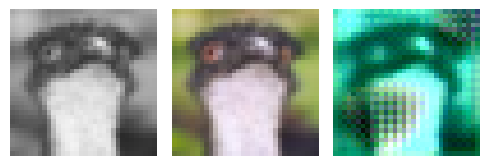

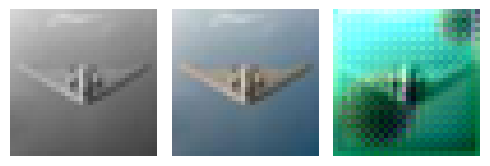

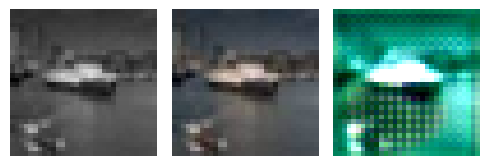

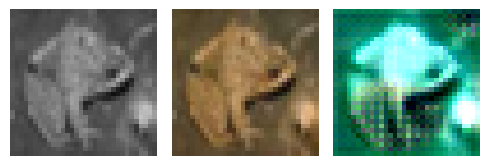

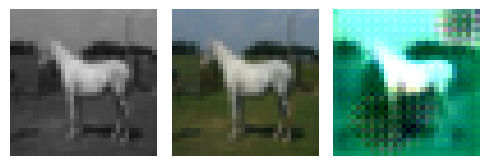

In [ ]:
model, optimizer, criterion = get_model() # inicializa modelo

exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
_val_dl = DataLoader(val_ds, batch_size=1, shuffle=True)

n_epochs = 100 # define o número
for ex in range(n_epochs):
    N = len(trn_dl)
    for bx, data in enumerate(trn_dl):
        loss = train_batch(model, data, optimizer, criterion) # treina o modelo

        # a cada 50 lotes gera uma prévia visual
        if(bx+1)%50 == 0:
            for _ in range(5):
                a, b = next(iter(_val_dl)) # pega um par
                _b = model(a) # o modelo tenta colorir
                subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5))

    for bx, data in enumerate(val_dl):
        loss = validate_batch(model, data, criterion)

    exp_lr_scheduler.step() # atualiza a taxa de aprendizado

    # exibe amostras finais
    for _ in range(5):
        a, b = next(iter(_val_dl))
        _b = model(a)
        subplots([a[0], b[0], _b[0]], nc=3, figsize=(5,5))